### Load data

In [1]:
import os
import sys
from glob import glob

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import shared.utils as su
from utils.video import read_frames_decord

### Load model

In [21]:
import torch
import torch.nn.functional as F
import requests
from PIL import Image
from transformers import AutoTokenizer
from transformers import LlavaNextProcessor, LlavaNextForConditionalGeneration


model_path = "/work/piyush/pretrained_checkpoints/e5-v"
processor = LlavaNextProcessor.from_pretrained(model_path)
model = LlavaNextForConditionalGeneration.from_pretrained(
    model_path, torch_dtype=torch.bfloat16, device_map="auto", attn_implementation='flash_attention_2',
)

llama3_template = '<|start_header_id|>user<|end_header_id|>\n\n{}<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n \n'

# img_prompt = llama3_template.format('<image>\nSummary above image in one word: ')
# text_prompt = llama3_template.format('<sent>\nSummary above sentence in one word: ')

img_prompt = llama3_template.format('<image>')
text_prompt = llama3_template.format('<sent>')

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.


### MSRVTT

In [2]:
data_root = "/scratch/shared/beegfs/piyush/datasets/MSRVTT"
image_dir = f"{data_root}/videos/mid_frames/"
video_dir = f"{data_root}/videos/all/"

data = su.io.load_json(f"{data_root}/annotation/msrvtt_test_1k.json")
df = pd.DataFrame(data)

df['video_path'] = df.video.apply(lambda x: f"{video_dir}/{x}")
df['video_path'].apply(os.path.exists).mean()

df['image_path'] = df.video.apply(lambda x: f"{image_dir}/{x.replace('.mp4', '.png')}")
df['image_path'].apply(os.path.exists).mean()

text_col = "caption"

df.shape, df.iloc[0].to_dict()

((1000, 11),
 {'video_id': 'video7020',
  'video': 'video7020.mp4',
  'caption': 'a woman creating a fondant baby and flower',
  'source': 'MSR-VTT',
  'category': 10,
  'url': 'https://www.youtube.com/watch?v=4KRMJNBjrEs',
  'start time': 221.77,
  'end time': 233.08,
  'id': 7020,
  'video_path': '/scratch/shared/beegfs/piyush/datasets/MSRVTT/videos/all//video7020.mp4',
  'image_path': '/scratch/shared/beegfs/piyush/datasets/MSRVTT/videos/mid_frames//video7020.png'})

In [4]:
df = df.sample(n=500)
df.shape

(500, 11)

In [5]:
captions = df.caption.tolist()
image_paths = df.image_path.tolist()

In [7]:
# urls = ['https://upload.wikimedia.org/wikipedia/commons/thumb/4/47/American_Eskimo_Dog.jpg/360px-American_Eskimo_Dog.jpg',
#         'https://upload.wikimedia.org/wikipedia/commons/thumb/b/b6/Felis_catus-cat_on_snow.jpg/179px-Felis_catus-cat_on_snow.jpg']
# images = [Image.open(requests.get(url, stream=True).raw) for url in urls]

images = [Image.open("../../TimeBound.v1/sample_data/folding_paper-0.png"), Image.open("../../TimeBound.v1/sample_data/folding_paper-0.png")]

texts = ['A dog sitting in the grass.',
         'A cat standing in the snow.']

text_inputs = processor([text_prompt.replace('<sent>', text) for text in texts], return_tensors="pt", padding=True).to('cuda')
img_inputs = processor([img_prompt]*len(images), images, return_tensors="pt", padding=True).to('cuda')

with torch.no_grad():
    text_embs = model(**text_inputs, output_hidden_states=True, return_dict=True).hidden_states[-1][:, -1, :]
    img_embs = model(**img_inputs, output_hidden_states=True, return_dict=True).hidden_states[-1][:, -1, :]

    text_embs = F.normalize(text_embs, dim=-1)
    img_embs = F.normalize(img_embs, dim=-1)

print(text_embs @ img_embs.t())

You may have used the wrong order for inputs. `images` should be passed before `text`. The `images` and `text` inputs will be swapped. This behavior will be deprecated in transformers v4.47.
Expanding inputs for image tokens in LLaVa-NeXT should be done in processing. Please add `patch_size` and `vision_feature_select_strategy` to the model's processing config or set directly with `processor.patch_size = {{patch_size}}` and processor.vision_feature_select_strategy = {{vision_feature_select_strategy}}`. Using processors without these attributes in the config is deprecated and will throw an error in v4.47.
Starting from v4.46, the `logits` model output will have the same type as the model (except at train time, where it will always be FP32)
Expanding inputs for image tokens in LLaVa-NeXT should be done in processing. Please add `patch_size` and `vision_feature_select_strategy` to the model's processing config or set directly with `processor.patch_size = {{patch_size}}` and processor.visi

tensor([[0.1553, 0.1553],
        [0.1543, 0.1543]], device='cuda:0', dtype=torch.bfloat16)


In [8]:
def embed_images(image_paths: list):
    images = [Image.open(f).convert("RGB") for f in image_paths]
    inputs = processor([img_prompt]*len(images), images, return_tensors="pt", padding=True).to('cuda')
    with torch.no_grad():
        embs = model(**inputs, output_hidden_states=True, return_dict=True).hidden_states[-1][:, -1, :]
        embs = F.normalize(embs, dim=-1).cpu().float()
    return embs


def embed_text(texts: list):
    inputs = processor([text_prompt.replace('<sent>', text) for text in texts], return_tensors="pt", padding=True).to('cuda')
    with torch.no_grad():
        embs = model(**inputs, output_hidden_states=True, return_dict=True).hidden_states[-1][:, -1, :]
        embs = F.normalize(embs, dim=-1).cpu().float()
    return embs

In [24]:
import numpy as np
from tqdm import tqdm

batch_size = 2
start_indices = np.arange(0, len(image_paths), batch_size)
embs_list = []
for si in tqdm(start_indices, desc="Embedding images"):
    image_batch = image_paths[si:si+batch_size]
    with torch.no_grad():
        embs = embed_images(image_batch)
    embs_list.append(embs)
embs_list = torch.cat(embs_list, dim=0)
embs_list.shape


start_indices = np.arange(0, len(captions), batch_size)
text_list = []
for si in tqdm(start_indices, desc="Embedding texts"):
    caps = captions[si:si+batch_size]
    with torch.no_grad():
        embs = embed_text(caps)
    text_list.append(embs)
text_list = torch.cat(text_list, dim=0)
text_list.shape

Embedding texts: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:40<00:00, 12.29it/s]


torch.Size([1000, 4096])

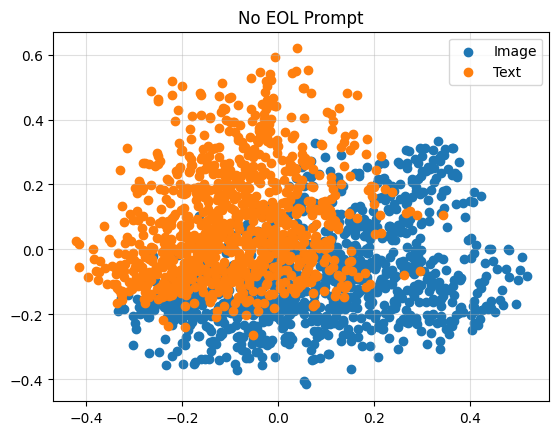

In [25]:
Z = torch.cat([embs_list, text_list])
z = su.visualize.reduce_dim(Z, method='pca')

plt.scatter(z[:len(image_paths), 0], z[:len(image_paths), 1], label='Image')
plt.scatter(z[len(image_paths):, 0], z[len(image_paths):, 1], label='Text')
plt.grid(alpha=0.4)
plt.legend()
plt.title("No EOL Prompt")
plt.show()

In [ ]:
video_embeds = {
    p: v for p, v in zip(image_paths, embs_list)
}
texts_embeds = {p: v for p, v in zip(captions, text_list)}
len(video_embeds), len(texts_embeds)

X = []
Y = [] 
for i in range(len(df)):
    row = df.iloc[i].to_dict()
    zv = video_embeds[row['image_path']]
    zt = texts_embeds[row[text_col]]
    X.append(zv)
    Y.append(zt)
norm = lambda x: torch.nn.functional.normalize(x, dim=-1)
X = norm(torch.stack(X))
Y = norm(torch.stack(Y))
delta = np.round((X.mean(dim=0) - Y.mean(dim=0)).norm(dim=-1).item(), 2)
delta

In [28]:
vid2text = {}
for f in video_embeds:
    vid2text[f] = df[df.image_path == f].iloc[0][text_col]
len(vid2text)

1000

In [29]:
def visualize_modality_gap(_video_embeds: dict, _texts_embeds: dict, vid2text: dict, method='tsne', save_path=None, title='Modality Gap'):
    norm = lambda x: torch.nn.functional.normalize(x, dim=-1)
    ZV = torch.stack([_video_embeds[f] for f in _video_embeds])
    ZT = torch.stack([_texts_embeds[t] for t in _texts_embeds])
    Z = torch.concatenate([ZV, ZT], dim=0)
    Z = norm(Z)
    z = su.visualize.reduce_dim(Z, method=method)

    delta = np.round((norm(ZV).mean(dim=0) - norm(ZT).mean(dim=0)).norm(dim=-1).item(), 3)

    # Create mappings from video/text to their index in z
    video_list = list(_video_embeds.keys())
    text_list = list(_texts_embeds.keys())
    
    fig, ax = plt.subplots(1, 1, figsize=(6, 5))
    
    # Draw matching lines first (so they appear behind the points)
    for i, f in enumerate(video_list):
        matched_text = vid2text[f]
        if matched_text in text_list:
            j = text_list.index(matched_text)
            # Draw line from video point to text point
            ax.plot([z[i, 0], z[len(ZV) + j, 0]], 
                    [z[i, 1], z[len(ZV) + j, 1]], 
                    color='lightgray', linewidth=0.5, alpha=0.5, zorder=1)
    
    # Draw scatter points on top
    ax.scatter(z[:len(ZV), 0], z[:len(ZV), 1], s=8, label='Video', zorder=2)
    ax.scatter(z[len(ZV):, 0], z[len(ZV):, 1], s=8, label='Text', zorder=2)
    
    ax.grid(alpha=0.3)
    ax.set_xlabel("$\\mathbf{z}_{1}$")
    ax.set_ylabel("$\\mathbf{z}_{2}$")
    ax.legend(fontsize=12)
    
    title += " (Delta = %s)" % np.round(delta, 3)
    print(title)
    ax.set_title(title, fontsize=14)

    if save_path is not None:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

With EOL Prompt (Delta = 0.311)


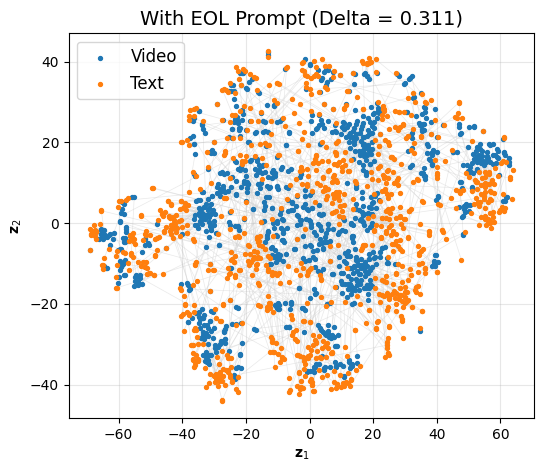

In [30]:
# save_path = '../figures/qwen3vlembedding8b-msrvtt-modgap.pdf'
# save_path = f'../figures/{model_key}-msrvtt-modgap.pdf'
# visualize_modality_gap(video_embeds, texts_embeds, vid2text, title="No EOL Prompt", method='tsne', save_path='../figures/llavanext-noeol.pdf')
visualize_modality_gap(video_embeds, texts_embeds, vid2text, title="With EOL Prompt", method='tsne', save_path='../figures/llavanext-eol.pdf')

### Images

In [2]:
import pandas as pd

df = pd.read_csv("./mscoco_t2i.csv")

# Sample 500 rows
df = df.sample(500)

df.shape

(500, 4)

In [3]:
captions = [i.split(": ")[1].strip("\n") for i in df['qry_text'].tolist()]
captions[:10]

['A woman sits on a luggage case on a sidewalk.',
 'A young girl is preparing to blow out her candle.',
 'A white toilet sitting next to a shower in a bathroom.',
 'A goat in a fied hangs out with other goats.',
 'View from gate of jet connected to jet way for passengers to board or deplane.',
 'A bunch of doughnuts with sprinkles on them.',
 'An E2 airplane painted blue with black and white stripes.',
 'An elephant and a rhinoceros stand not far from each other.',
 'A painting that has a gold frame on it.',
 'A pizza sliced in four slices on a plate.']

In [4]:
import numpy as np

data_dir = "/scratch/shared/beegfs/piyush/datasets/MMEB-V2/image-tasks/MMEB"
image_ids = eval(df['tgt_img_path'].iloc[0])
image_ids = np.random.choice(image_ids, size=500, replace=False)

image_paths =[f"{data_dir}/{x}" for x in image_ids]
image_paths[:4]

['/scratch/shared/beegfs/piyush/datasets/MMEB-V2/image-tasks/MMEB/MSCOCO_t2i/COCO_val2014_000000393145.jpg',
 '/scratch/shared/beegfs/piyush/datasets/MMEB-V2/image-tasks/MMEB/MSCOCO_t2i/COCO_val2014_000000572733.jpg',
 '/scratch/shared/beegfs/piyush/datasets/MMEB-V2/image-tasks/MMEB/MSCOCO_t2i/COCO_val2014_000000027226.jpg',
 '/scratch/shared/beegfs/piyush/datasets/MMEB-V2/image-tasks/MMEB/MSCOCO_t2i/COCO_val2014_000000169858.jpg']

In [5]:
def embed_images(image_paths: list):
    images = [Image.open(f) for f in image_paths]
    inputs = processor([img_prompt]*len(images), images, return_tensors="pt", padding=True).to('cuda')
    with torch.no_grad():
        embs = model(**inputs, output_hidden_states=True, return_dict=True).hidden_states[-1][:, -1, :]
        embs = F.normalize(embs, dim=-1).cpu().float()
    return embs


def embed_text(texts: list):
    inputs = processor([text_prompt.replace('<sent>', text) for text in texts], return_tensors="pt", padding=True).to('cuda')
    with torch.no_grad():
        embs = model(**inputs, output_hidden_states=True, return_dict=True).hidden_states[-1][:, -1, :]
        embs = F.normalize(embs, dim=-1).cpu().float()
    return embs



In [13]:
embed_images(['../assets/logo.png']).shape, embed_text(['A dog sitting in the grass.']).shape

(torch.Size([1, 4096]), torch.Size([1, 4096]))

In [22]:
import numpy as np
from tqdm import tqdm

batch_size = 2
start_indices = np.arange(0, len(image_paths), batch_size)
embs_list = []
for si in su.log.tqdm_iterator(start_indices, desc="Embedding images"):
    image_batch = image_paths[si:si+batch_size]
    with torch.no_grad():
        embs = embed_images(image_batch)
    embs_list.append(embs)
embs_list = torch.cat(embs_list, dim=0)
embs_list.shape


start_indices = np.arange(0, len(captions), batch_size)
text_list = []
for si in su.log.tqdm_iterator(start_indices, desc="Embedding texts"):
    caps = captions[si:si+batch_size]
    with torch.no_grad():
        embs = embed_text(caps)
    text_list.append(embs)
text_list = torch.cat(text_list, dim=0)
text_list.shape

Embedding images:   0%|          | 0/250 [00:00<?, ?it/s]

Embedding texts:   0%|          | 0/250 [00:00<?, ?it/s]

torch.Size([500, 4096])

In [23]:
video_embeds = {
    p: v for p, v in zip(image_paths, embs_list)
}
texts_embeds = {p: v for p, v in zip(captions, text_list)}
len(video_embeds), len(texts_embeds)

X = []
Y = [] 
for i in range(len(df)):
    row = df.iloc[i].to_dict()
    zv = video_embeds[image_paths[i]]
    zt = texts_embeds[captions[i]]
    X.append(zv)
    Y.append(zt)
norm = lambda x: torch.nn.functional.normalize(x, dim=-1)
X = norm(torch.stack(X))
Y = norm(torch.stack(Y))
delta = np.round((X.mean(dim=0) - Y.mean(dim=0)).norm(dim=-1).item(), 2)
delta

0.48

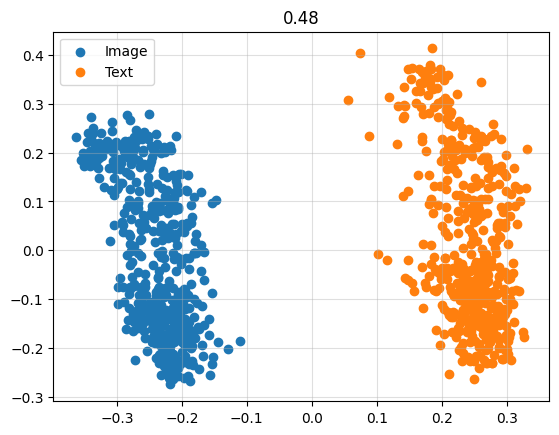

In [24]:
Z = torch.cat([embs_list, text_list])
z = su.visualize.reduce_dim(Z, method='pca')

plt.scatter(z[:len(image_paths), 0], z[:len(image_paths), 1], label='Image')
plt.scatter(z[len(image_paths):, 0], z[len(image_paths):, 1], label='Text')
plt.grid(alpha=0.4)
plt.legend()
plt.title(delta)
plt.show()

In [6]:
from models.modeling_encoders import AutoEncoder
import torch

model_path = "/work/piyush/pretrained_checkpoints/Qwen2-VL-7B-Instruct/"
model = AutoEncoder.from_pretrained(model_path, torch_dtype=torch.bfloat16, device_map="auto", attn_implementation='flash_attention_2')

Unrecognized keys in `rope_scaling` for 'rope_type'='default': {'mrope_section'}
`Qwen2VLRotaryEmbedding` can now be fully parameterized by passing the model config through the `config` argument. All other arguments will be removed in v4.46


Failed to import Qwen2_5_VLModel, Qwen2_5_VLForConditionalGeneration.
Loading EncoderForQwen2VL from /work/piyush/pretrained_checkpoints/Qwen2-VL-7B-Instruct/


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

In [7]:
def read_image(image_path):
    import PIL
    image = PIL.Image.open(image_path)
    image = torch.tensor(np.asarray(image)).unsqueeze(0)
    image = image.permute((0, 3, 1, 2))
    return image


x = read_image("1.png")
print(x.shape)

z = model.encode_vision(x.unsqueeze(0), prompt="<video>").squeeze(0).cpu().float()
print(z.shape)

torch.Size([1, 3, 400, 400])


From v4.47 onwards, when a model cache is to be returned, `generate` will return a `Cache` instance instead by default (as opposed to the legacy tuple of tuples format). If you want to keep returning the legacy format, please set `return_legacy_cache=True`.


torch.Size([3584])


In [11]:
from tqdm import tqdm

embs_list = []
for i in tqdm(range(len(image_paths))):
    with torch.no_grad():
        # z = model.encode_vision(read_image(image_paths[i]).unsqueeze(0), prompt='<video>').squeeze(0).cpu().float()
        z = model.encode_vision(read_image(image_paths[i]).unsqueeze(0), prompt=None).squeeze(0).cpu().float()
        embs_list.append(z)
embs_list = torch.stack(embs_list)
embs_list.shape

text_list = []
for i in tqdm(range(len(captions))):
    with torch.no_grad():
        # z = model.encode_text(captions[i], prompt='<sent>').squeeze(0).cpu().float()
        z = model.encode_text(captions[i], prompt=None).squeeze(0).cpu().float()
        text_list.append(z)
text_list = torch.stack(text_list)
text_list.shape

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:26<00:00, 19.20it/s]


torch.Size([500, 3584])

In [12]:
video_embeds = {
    p: v for p, v in zip(image_paths, embs_list)
}
texts_embeds = {p: v for p, v in zip(captions, text_list)}
len(video_embeds), len(texts_embeds)

X = []
Y = [] 
for i in range(len(df)):
    row = df.iloc[i].to_dict()
    zv = video_embeds[image_paths[i]]
    zt = texts_embeds[captions[i]]
    X.append(zv)
    Y.append(zt)
norm = lambda x: torch.nn.functional.normalize(x, dim=-1)
X = norm(torch.stack(X))
Y = norm(torch.stack(Y))
delta = np.round((X.mean(dim=0) - Y.mean(dim=0)).norm(dim=-1).item(), 2)
delta

0.42

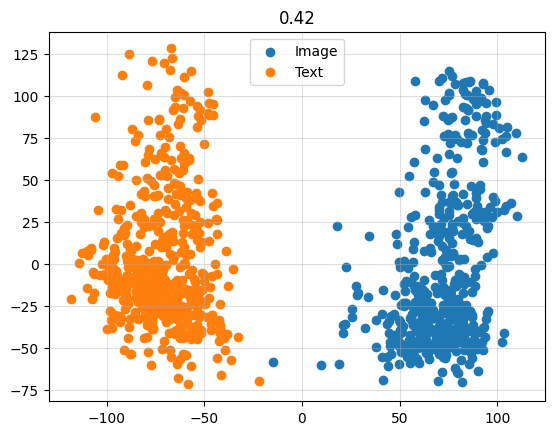

In [13]:
Z = torch.cat([embs_list, text_list])
z = su.visualize.reduce_dim(Z, method='pca')

plt.scatter(z[:len(image_paths), 0], z[:len(image_paths), 1], label='Image')
plt.scatter(z[len(image_paths):, 0], z[len(image_paths):, 1], label='Text')
plt.grid(alpha=0.4)
plt.legend()
plt.title(delta)
plt.show()